# Gallifrey

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as mpl
import torch
import torch.nn as nn
import warnings
import joblib
import os

from scipy.fft import fft, fftfreq
from scipy import signal

In [18]:
warnings.filterwarnings('ignore')

In [19]:
mpl.style.use('dark_background')

In [20]:
PALETTE = ['#00D4FF', '#FF6B35', '#7FFF00', '#FFD700', '#FF69B4', '#9B59B6']
sns.set_palette(PALETTE)

In [21]:
os.makedirs('models', exist_ok=True)
os.makedirs('figures', exist_ok=True)

In [25]:
np.random.seed(42)
torch.manual_seed(42)
print("42 Ready :D")

42 Ready :D


## 1. Data Loading and EDA

In [27]:
DT_PATH  = 'digitaltwin.csv'
ACC_PATH = 'sensor.csv'

In [28]:
dt  = pd.read_csv(DT_PATH,  parse_dates=['Timestamp'])
acc  = pd.read_csv(ACC_PATH,  parse_dates=['Timestamp'])

In [34]:
print("----- Digital Twin: -----")
print(f"Shape: {dt.shape} Time range: {dt["Timestamp"].min()} → {dt["Timestamp"].max()}\n")
print(dt.head(5))

print("*"*100)

print("----- Accelerometer: -----")
print(f"Shape: {acc.shape}  |  Time range: {acc["Timestamp"].min()} → {acc["Timestamp"].max()}")
print(dt.head(5))

----- Digital Twin: -----
Shape: (43200, 54) Time range: 2023-01-01 00:00:00 → 2023-01-30 23:59:00

            Timestamp  Strain_microstrain  Deflection_mm  Vibration_ms2  \
0 2023-01-01 00:00:00                 NaN      12.663104       1.275955   
1 2023-01-01 00:01:00          599.936448      12.235297       0.716857   
2 2023-01-01 00:02:00          573.878472      12.447144       0.834753   
3 2023-01-01 00:03:00          550.457302      12.554883       1.004917   
4 2023-01-01 00:04:00          572.829960      12.598818       1.176253   

   Tilt_deg  Displacement_mm  Crack_Propagation_mm  Corrosion_Level_percent  \
0  0.587340        22.576518             -0.000083                 0.002910   
1  0.657122        21.202649              0.000092                 0.004601   
2  0.615011              NaN             -0.000377                 0.005115   
3  0.617999        21.551945             -0.000646                 0.005505   
4  0.633534        21.711292              0.000247    

## 2. Missing Values Analysis

In [37]:
def missing_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'missing': missing, 'pct': pct})
    report = report[report['missing'] > 0].sort_values('pct', ascending=False)
    print(f'\n{name}: {len(report)} columns with missing values')
    return report

dt_missing  = missing_report(dt,  'Digital Twin')
acc_missing = missing_report(acc, 'Accelerometer')
display(dt_missing.head(15))


Digital Twin: 53 columns with missing values

Accelerometer: 5 columns with missing values


,missing,pct
Vibration_Anomaly_Location,34155,79.06
Strain_microstrain,1821,4.22
Humidity_percent,1783,4.13
Estimated_Repair_Cost_USD_incremental,1771,4.10
Wind_Direction_deg,1768,4.09
Landslide_Ground_Movement,1765,4.09
Abnormal_Traffic_Load_Surges,1763,4.08
High_Winds_Storms,1758,4.07
Vehicle_Load_tons,1756,4.06
Tilt_deg,1753,4.06


In [39]:
# statistics for key structural columns
KEY_STRUCTURAL = [
    'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2',
    'Displacement_mm', 'Crack_Propagation_mm', 'Corrosion_Level_percent',
    'Modal_Frequency_Hz', 'Structural_Health_Index_SHI',
    'Probability_of_Failure_PoF'
]

dt[KEY_STRUCTURAL].describe().T.style.background_gradient(cmap='RdYlGn_r')

,count,mean,std,min,25%,50%,75%,max
Strain_microstrain,41379.000000,851.950836,351.908310,363.529753,618.866446,734.476653,1072.661680,4074.893156
Deflection_mm,41467.000000,15.145403,3.824032,6.889697,12.447132,14.986160,17.090508,30.389080
Vibration_ms2,41478.000000,1.339495,0.979641,0.637735,1.000030,1.198123,1.532924,15.086480
Displacement_mm,41473.000000,22.703596,1.627841,18.964441,21.387484,22.361439,23.985103,27.630262
Crack_Propagation_mm,41494.000000,0.015036,0.009338,-0.001531,0.007511,0.015024,0.022526,0.519706
Corrosion_Level_percent,41531.000000,0.149950,0.086731,-0.010256,0.074979,0.150101,0.224839,0.312679
Modal_Frequency_Hz,41481.000000,1.895313,0.100269,1.353801,1.825477,1.895834,1.968278,2.235211
Structural_Health_Index_SHI,41500.000000,0.815885,0.052818,0.292081,0.797134,0.822936,0.845468,0.907657
Probability_of_Failure_PoF,41456.000000,0.034029,0.017626,0.019160,0.027351,0.030689,0.035370,0.708676


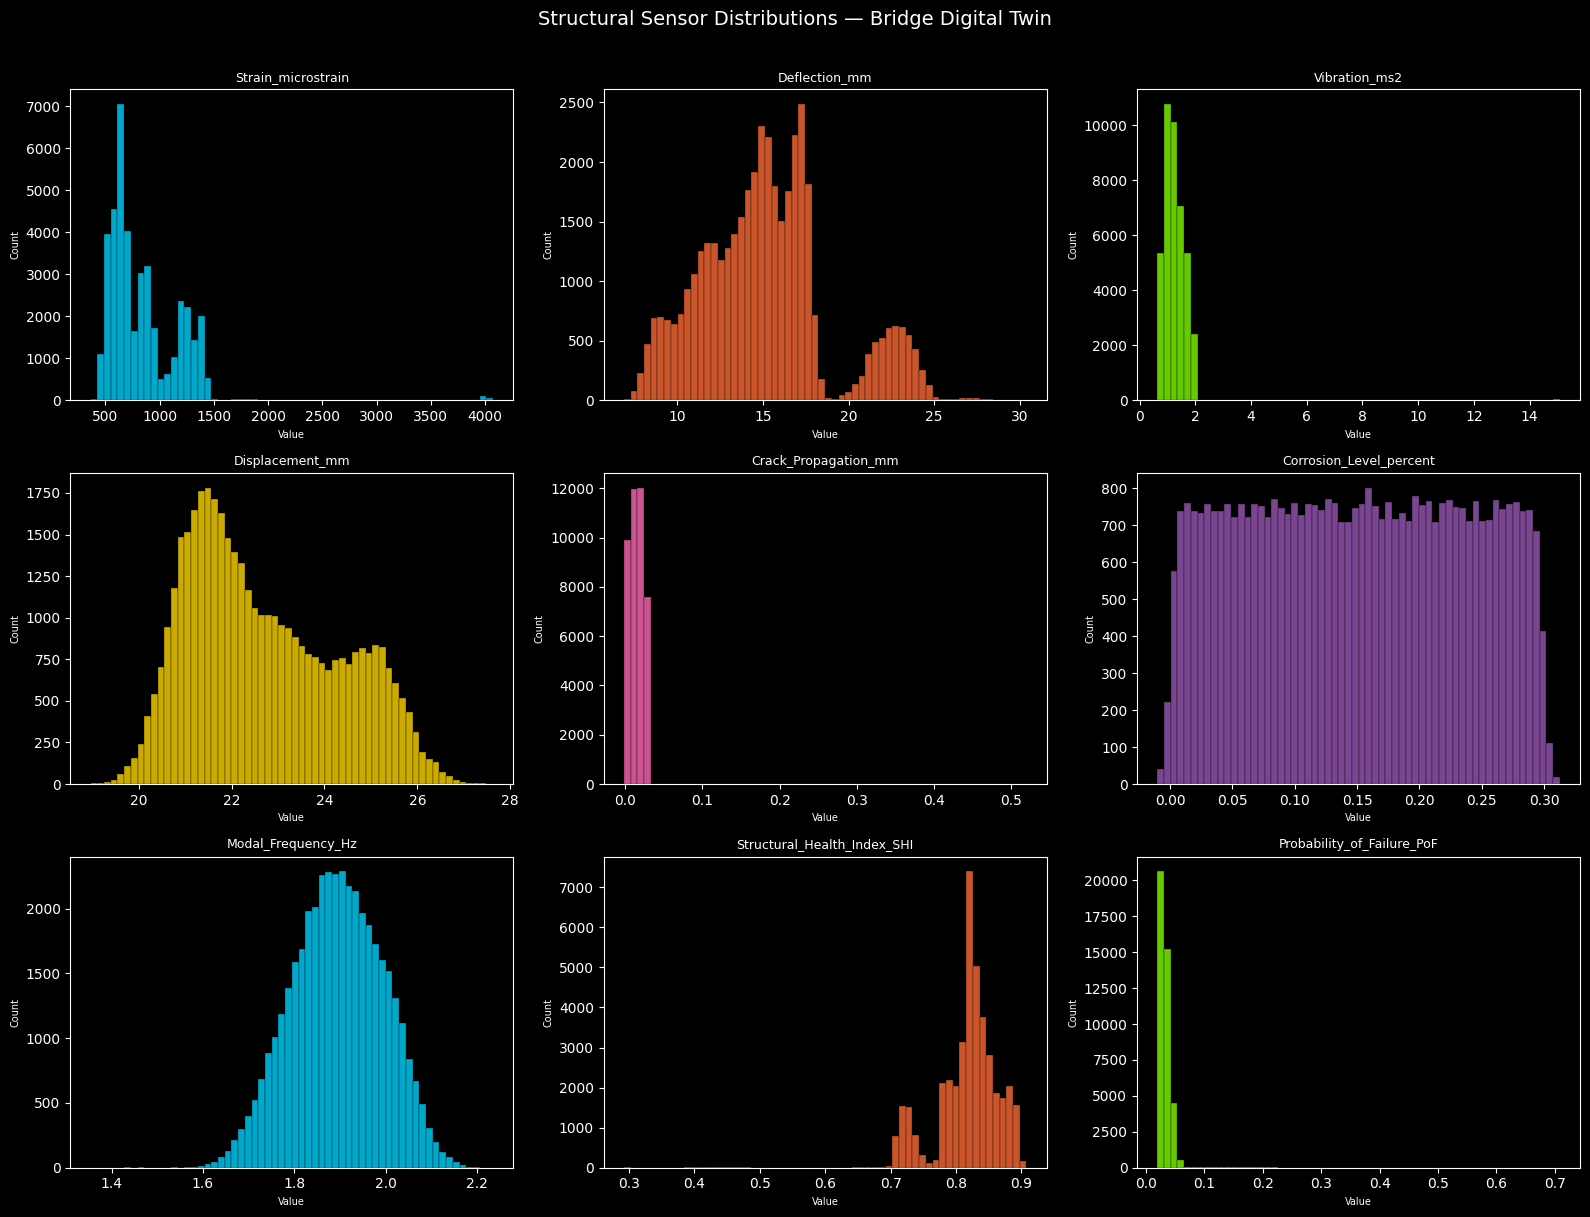

In [43]:
# Distribution plots for structural health indicators
fig, axes = mpl.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(KEY_STRUCTURAL):
    if col in dt.columns:
        axes[i].hist(dt[col].dropna(), bins=60, color=PALETTE[i % len(PALETTE)], 
                     alpha=0.8, edgecolor='black', linewidth=0.3)
        axes[i].set_title(col, fontsize=9, color='white')
        axes[i].set_xlabel('Value', fontsize=7)
        axes[i].set_ylabel('Count', fontsize=7)

mpl.suptitle('Structural Sensor Distributions — Bridge Digital Twin', 
             fontsize=14, color='white', y=1.01)
mpl.tight_layout()
mpl.savefig('figures/distributions.png', dpi=150, bbox_inches='tight')
mpl.show() 	15.086480

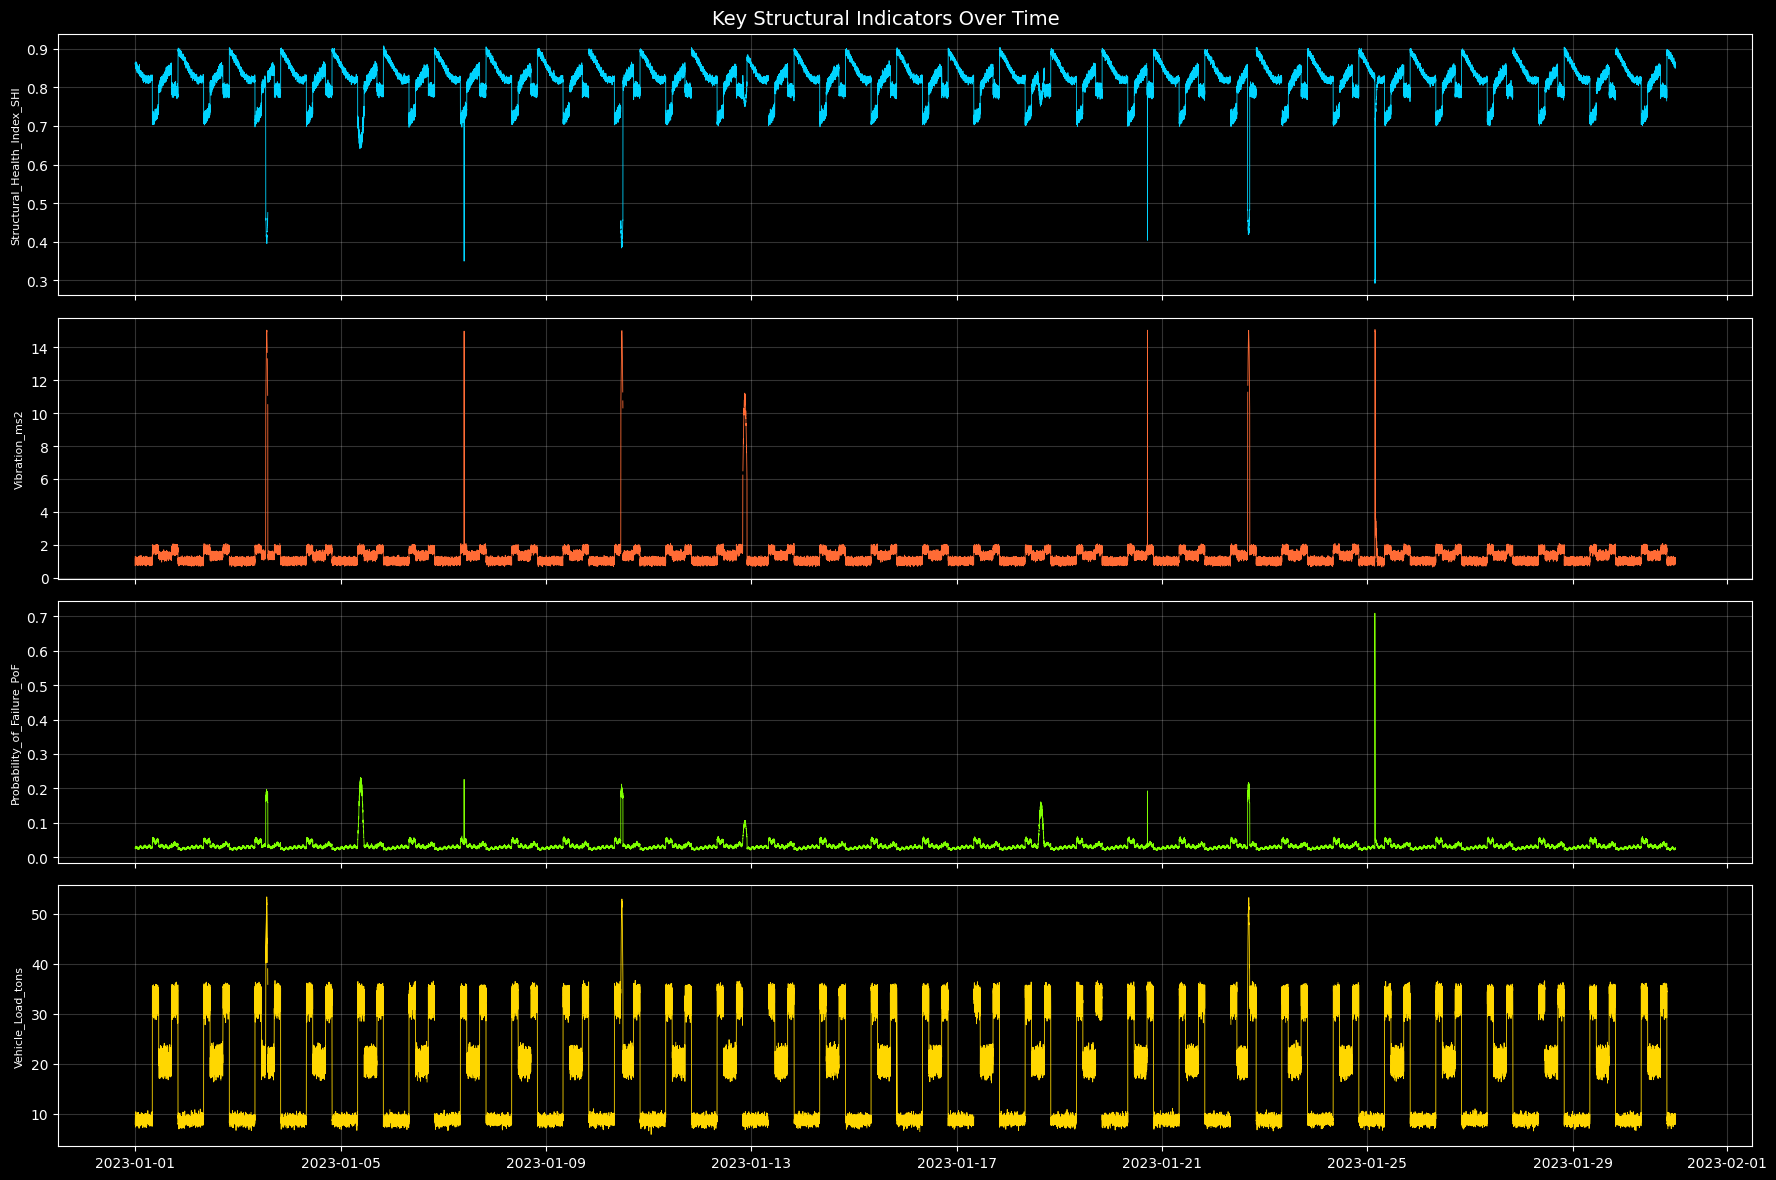

In [46]:
# Timeseries analysis
fig, axes = mpl.subplots(4, 1, figsize=(18, 12), sharex=True)
ts_cols = ['Structural_Health_Index_SHI', 'Vibration_ms2', 
           'Probability_of_Failure_PoF', 'Vehicle_Load_tons']

for ax, col in zip(axes, ts_cols):
    if col in dt.columns:
        ax.plot(dt['Timestamp'], dt[col], linewidth=0.6, color=PALETTE[ts_cols.index(col)])
        ax.set_ylabel(col, fontsize=8)
        ax.grid(alpha=0.2)

mpl.suptitle('Key Structural Indicators Over Time', fontsize=14, color='white')
mpl.tight_layout()
mpl.savefig('figures/timeseries_overview.png', dpi=150, bbox_inches='tight')
mpl.show()

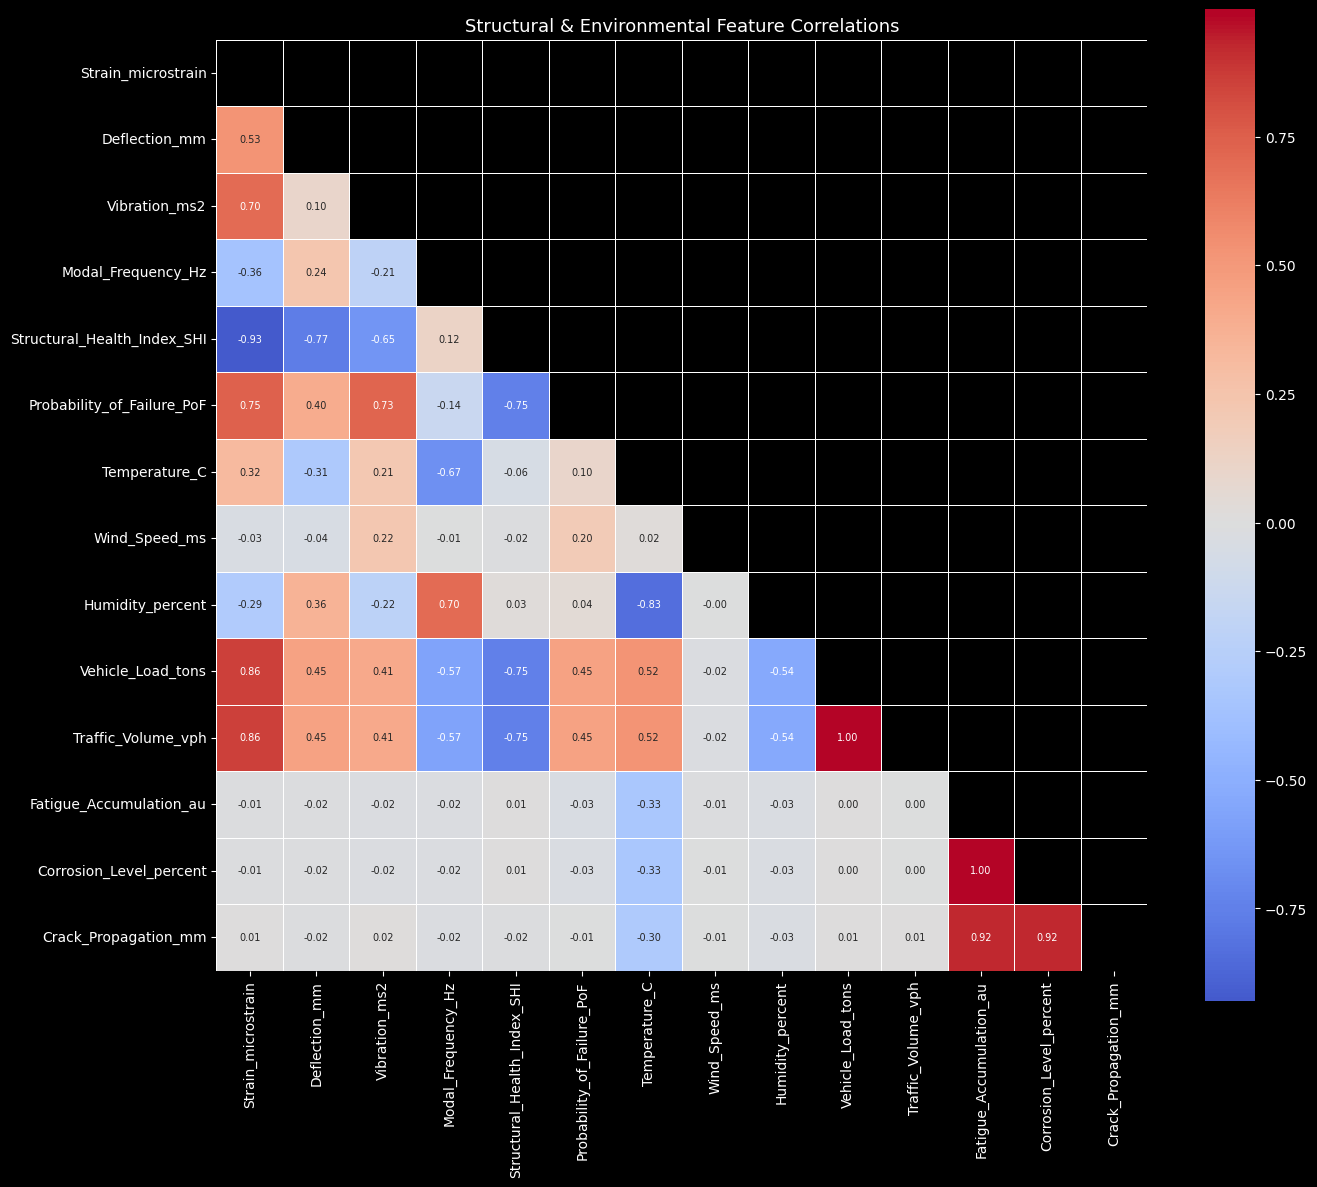

In [49]:
# Correlation Heatmap
CORR_COLS = [
    'Strain_microstrain', 'Deflection_mm', 'Vibration_ms2', 'Modal_Frequency_Hz',
    'Structural_Health_Index_SHI', 'Probability_of_Failure_PoF',
    'Temperature_C', 'Wind_Speed_ms', 'Humidity_percent',
    'Vehicle_Load_tons', 'Traffic_Volume_vph', 'Fatigue_Accumulation_au',
    'Corrosion_Level_percent', 'Crack_Propagation_mm'
]
CORR_COLS = [c for c in CORR_COLS if c in dt.columns]

fig, ax = mpl.subplots(figsize=(14, 12))
corr = dt[CORR_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Structural & Environmental Feature Correlations', fontsize=13, color='white')
mpl.tight_layout()
mpl.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
mpl.show()

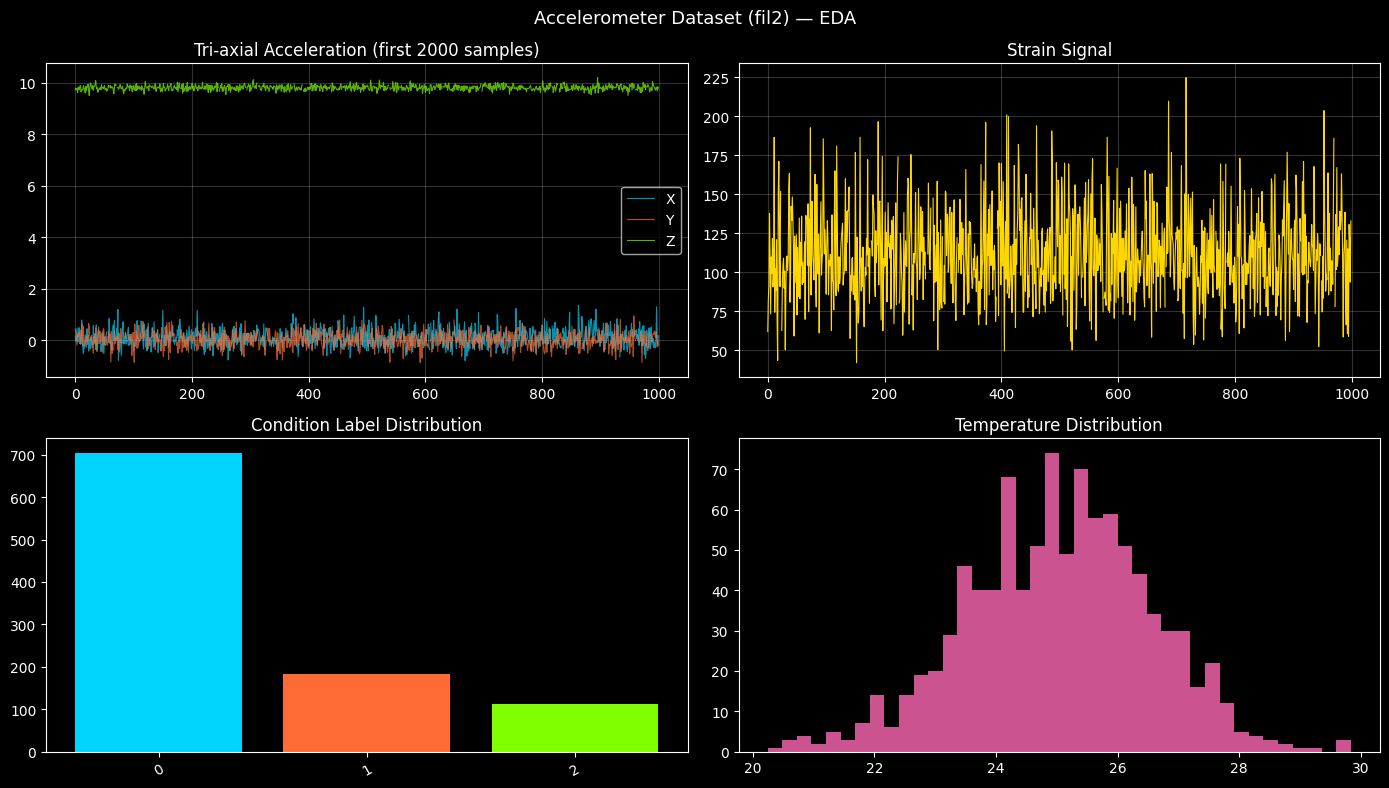

In [51]:
# Accelerometer dataset EDA
fig, axes = mpl.subplots(2, 2, figsize=(14, 8))

# Tri-axial acceleration
for ax_name, col, color in zip(['X','Y','Z'], 
    ['Accel_X (m/s^2)', 'Accel_Y (m/s^2)', 'Accel_Z (m/s^2)'], PALETTE):
    axes[0,0].plot(acc[col].values[:2000], alpha=0.7, label=ax_name, color=color, linewidth=0.8)
axes[0,0].set_title('Tri-axial Acceleration (first 2000 samples)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.2)

# Strain
axes[0,1].plot(acc['Strain (με)'].values[:2000], color=PALETTE[3], linewidth=0.8)
axes[0,1].set_title('Strain Signal')
axes[0,1].grid(alpha=0.2)

# Condition label distribution
if 'Condition Label' in acc.columns:
    label_counts = acc['Condition Label'].value_counts()
    axes[1,0].bar(label_counts.index.astype(str), label_counts.values, color=PALETTE[:len(label_counts)])
    axes[1,0].set_title('Condition Label Distribution')
    axes[1,0].tick_params(axis='x', rotation=30)

# Temperature distribution
axes[1,1].hist(acc['Temp (°C)'].dropna(), bins=40, color=PALETTE[4], alpha=0.8)
axes[1,1].set_title('Temperature Distribution')

mpl.suptitle('Accelerometer Dataset (fil2) — EDA', fontsize=13)
mpl.tight_layout()
mpl.savefig('figures/acc_eda.png', dpi=150, bbox_inches='tight')
mpl.show()

## 3. FFT

In [53]:
from scipy.fft import rfft, rfftfreq

In [55]:
def compute_fft(signal_data, fs=100):
    """Compute FFT and return freq, magnitudes"""
    N = len(signal_data)
    yf = np.abs(fft(signal_data - signal_data.mean()))[:N//2]
    xf = fftfreq(N, 1/fs)[:N//2]
    return xf, yf

In [92]:
def plot_fft_comparison(sig1, sig2, title="FFT comparison"):

    sig1 = np.asarray(sig1)
    sig2 = np.asarray(sig2)

    fft1 = np.abs(np.fft.rfft(sig1)) / len(sig1)
    fft2 = np.abs(np.fft.rfft(sig2)) / len(sig2)

    fs = 100  # sensor sampling rate
    freq1 = np.fft.rfftfreq(len(sig1), d=1/fs)
    freq2 = np.fft.rfftfreq(len(sig2), d=1/fs)

    mask1 = freq1 > 0.5
    mask2 = freq2 > 0.5

    freq1 = freq1[mask1]
    fft1 = fft1[mask1]

    freq2 = freq2[mask2]
    fft2 = fft2[mask2]


    freq1 = freq1[1:]
    fft1 = fft1[1:]

    freq2 = freq2[1:]
    fft2 = fft2[1:]
    fig, ax = mpl.subplots()

    ax.plot(freq1, fft1, label="Healthy")
    ax.plot(freq2, fft2, label="Damaged")

    ax.set_title(title)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Amplitude")
    ax.legend()

    return fig


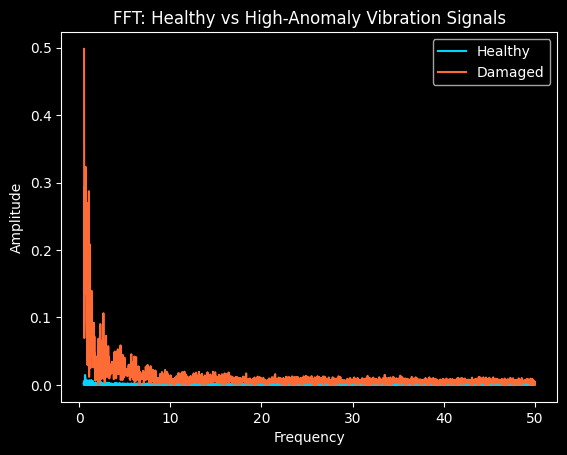

In [93]:
if 'Vibration_ms2' in dt.columns and 'Anomaly_Detection_Score' in dt.columns:

    anomaly_thresh = dt['Vibration_ms2'].quantile(0.90)

    healthy_vib = dt.loc[
    dt['Vibration_ms2'] < anomaly_thresh,
        'Vibration_ms2'
    ].dropna()

    damaged_vib = dt.loc[
        dt['Vibration_ms2'] >= anomaly_thresh,
        'Vibration_ms2'
    ].dropna()

    healthy_vib = healthy_vib - healthy_vib.mean()
    damaged_vib = damaged_vib - damaged_vib.mean()

    if len(healthy_vib) > 64 and len(damaged_vib) > 64:

        fig = plot_fft_comparison(
            healthy_vib,
            damaged_vib,
            title="FFT: Healthy vs High-Anomaly Vibration Signals"
        )

        fig.savefig("figures/fft_comparison.png", dpi=150, bbox_inches="tight")
        mpl.show()

    else:
        print("Not enough vibration samples for FFT")

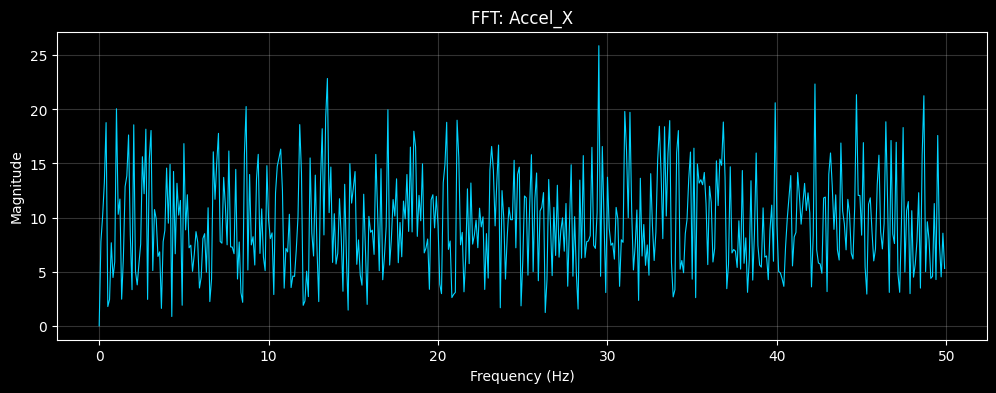

In [94]:
accel_x = acc['Accel_X (m/s^2)'].dropna().values
xf, yf = compute_fft(accel_x[:4096], fs=100)
mpl.figure(figsize=(12, 4))
mpl.plot(xf, yf, color=PALETTE[0], linewidth=0.8)
mpl.xlabel('Frequency (Hz)')
mpl.ylabel('Magnitude')
mpl.title('FFT: Accel_X')
mpl.grid(alpha=0.2)
mpl.savefig('figures/fft_accelx.png', dpi=150, bbox_inches='tight')
mpl.show()

## Wavelet Transform & Local Power Spectra
Integrating the custom modules from `algos.wavelet_transform` to perform advanced signal processing on the accelerometer data.

In [97]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from algos.wavelet_transform.wavelet_fft import wavelet_transform
from algos.wavelet_transform.local_power_spectra import compute_lps
from algos.wavelet_transform.utils import evolutionary_psd
from algos.wavelet_transform.structural_response import duhamel_response
from algos.wavelet_transform.reliability_analysis import upcrossing_rate, reliability_probability


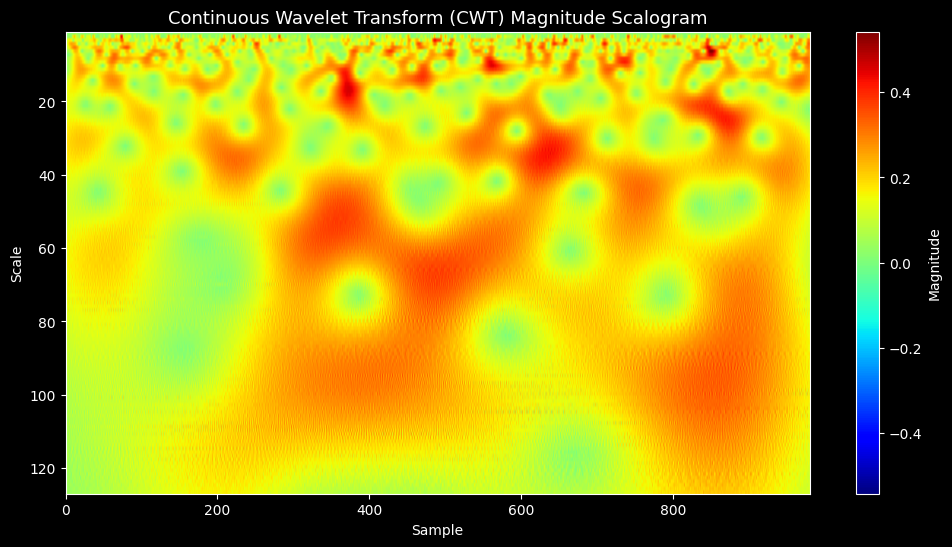

In [106]:
# 1. Wavelet Transform

scales = np.arange(1, 128)
signal_to_process = accel_x[:4096] # using the same segment as FFT
coeff_mags = wavelet_transform(signal_to_process, scales, wavelet='cmor1.5-1.0')

fig, ax = mpl.subplots(figsize=(12, 6))
c = ax.imshow(coeff_mags, extent=[0, len(signal_to_process), scales[-1], scales[0]], cmap='jet', aspect='auto', vmax=abs(coeff_mags).max(), vmin=-abs(coeff_mags).max())
fig.colorbar(c, ax=ax, label='Magnitude')
ax.set_title('Continuous Wavelet Transform (CWT) Magnitude Scalogram', color='white', fontsize=13)
ax.set_ylabel('Scale', color='white')
ax.set_xlabel('Sample', color='white')
mpl.savefig('figures/cwt_scalogram.png', dpi=150, bbox_inches='tight')
mpl.show()

In [110]:
import importlib
from algos.wavelet_transform import local_power_spectra
importlib.reload(local_power_spectra)
from algos.wavelet_transform.local_power_spectra import compute_lps


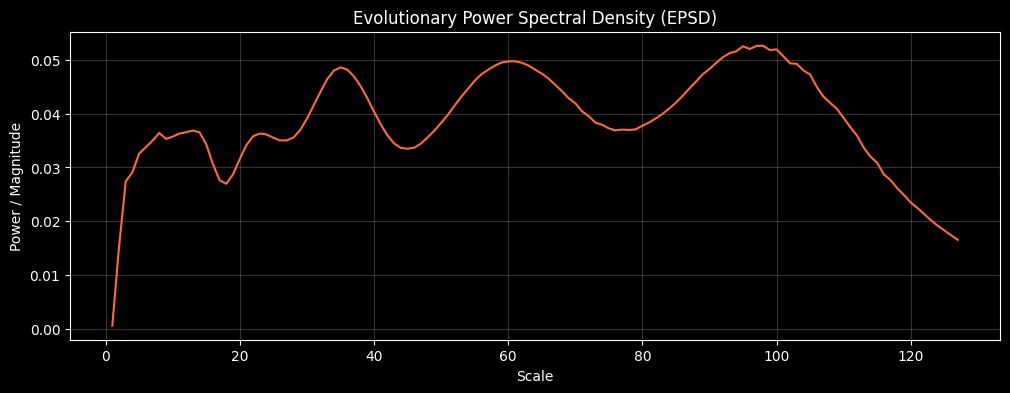

In [111]:
# 2. Local Power Spectra (LPS) & Evolutionary PSD
lps = compute_lps(coeff_mags)
epsd = evolutionary_psd(lps)

fig, ax = mpl.subplots(figsize=(12, 4))
ax.plot(scales, epsd, color=PALETTE[1], linewidth=1.5)
ax.set_title('Evolutionary Power Spectral Density (EPSD)', color='white')
ax.set_xlabel('Scale', color='white')
ax.set_ylabel('Power / Magnitude', color='white')
ax.grid(alpha=0.2)
mpl.savefig('figures/epsd.png', dpi=150, bbox_inches='tight')
mpl.show()

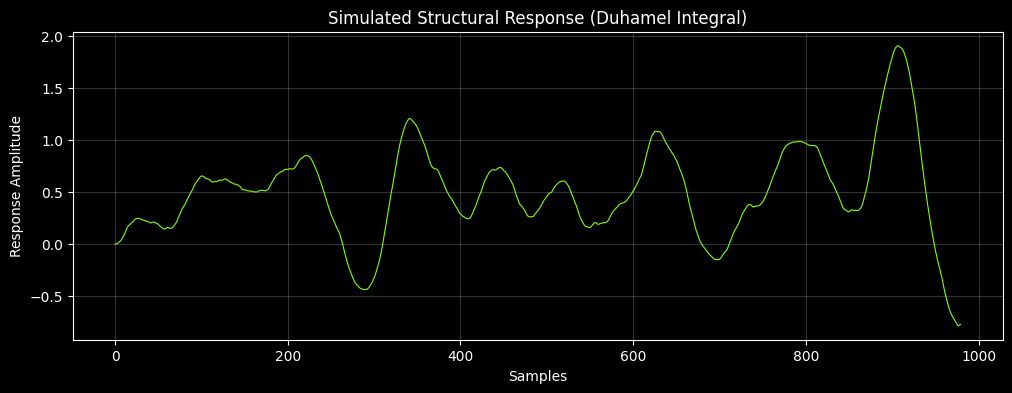

In [113]:
# 3. Structural Response (Duhamel Integral)
# Defining a simple impulse response for an underdamped system (SDOF)

t = np.linspace(0, 10, len(signal_to_process))
m, c, k = 1.0, 0.5, 20.0 # Mass, Damping, Stiffness
omega_n = np.sqrt(k/m)
zeta = c / (2 * np.sqrt(k*m))
omega_d = omega_n * np.sqrt(1 - zeta**2)
impulse_response = (1 / (m * omega_d)) * np.exp(-zeta * omega_n * t) * np.sin(omega_d * t)

response = duhamel_response(signal_to_process, impulse_response)

fig, ax = mpl.subplots(figsize=(12, 4))
ax.plot(response, color=PALETTE[2], linewidth=0.8)
ax.set_title('Simulated Structural Response (Duhamel Integral)', color='white')
ax.set_xlabel('Samples', color='white')
ax.set_ylabel('Response Amplitude', color='white')
ax.grid(alpha=0.2)
mpl.savefig('figures/structural_response.png', dpi=150, bbox_inches='tight')
mpl.show()

Mean upcrossing rate (v_b): 0.0074


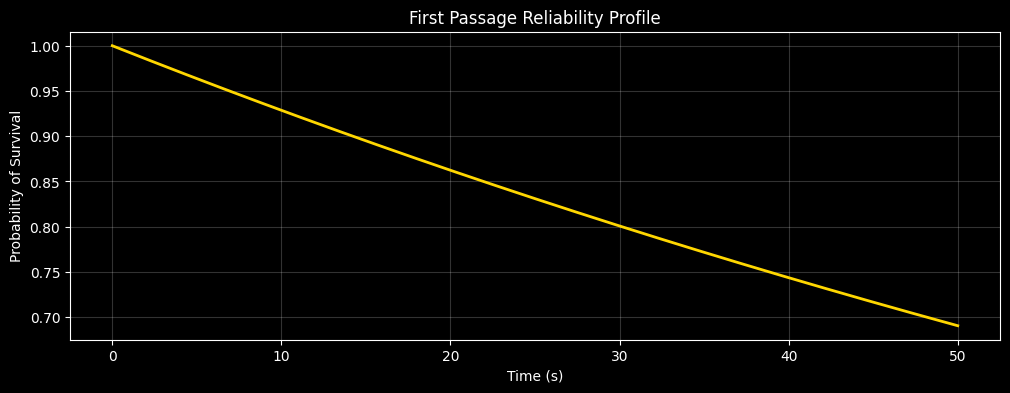

In [114]:
# 4. First Passage Reliability Analysis
# Using response statistics

a0 = np.var(response)
response_diff = np.diff(response)
a2 = np.var(response_diff) # Variance of derivative

up_rate = upcrossing_rate(a0, a2)
print(f"Mean upcrossing rate (v_b): {up_rate:.4f}")

# Reliability over time (assuming t is in seconds corresponding to the signal)
time_horizon = np.linspace(0, 50, 500)
reliability = reliability_probability(up_rate, time_horizon)

fig, ax = mpl.subplots(figsize=(12, 4))
ax.plot(time_horizon, reliability, color=PALETTE[3], linewidth=2)
ax.set_title('First Passage Reliability Profile', color='white')
ax.set_xlabel('Time (s)', color='white')
ax.set_ylabel('Probability of Survival', color='white')
ax.grid(alpha=0.2)
mpl.savefig('figures/reliability_profile.png', dpi=150, bbox_inches='tight')
mpl.show()

## 5. Feature Extraction Pipeline

Here we build a robust feature extraction pipeline to transform raw vibration signals into tabular features for Machine Learning models. We extract:
- **Statistical Moments**: Mean, variance, skewness, kurtosis, peak-to-peak.
- **Frequency Domain Features**: Peak frequency, spectral centroid, spectral energy.
- **Time-Frequency Domain (Wavelet)**: Total wavelet energy, energy concentrations across different scales.

In [115]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch

def extract_features(signal_data, fs=100):
    features = {}
    
    # 1. Statistical Time-Domain Features
    features['mean'] = np.mean(signal_data)
    features['std'] = np.std(signal_data)
    features['var'] = np.var(signal_data)
    features['max'] = np.max(signal_data)
    features['min'] = np.min(signal_data)
    features['peak_to_peak'] = features['max'] - features['min']
    features['skewness'] = skew(signal_data)
    features['kurtosis'] = kurtosis(signal_data)
    features['rms'] = np.sqrt(np.mean(signal_data**2))
    features['crest_factor'] = features['max'] / features['rms'] if features['rms'] > 0 else 0
    
    # 2. Frequency Domain Features (FFT / PSD)
    freqs, psd = welch(signal_data, fs, nperseg=1024)
    features['peak_freq'] = freqs[np.argmax(psd)]
    features['spectral_centroid'] = np.sum(freqs * psd) / np.sum(psd) if np.sum(psd) > 0 else 0
    features['spectral_energy'] = np.sum(psd)
    
    # 3. Time-Frequency Domain Features (Wavelet / LPS)
    scales = np.arange(1, 128)
    # Using a fast discreet or continuous wavelet transform to get coefficient magnitudes
    coeff_mags = wavelet_transform(signal_data, scales, wavelet='cmor1.5-1.0')
    
    lps = compute_lps(coeff_mags) # Average power over time
    epsd = evolutionary_psd(lps)  # Evolutionary PSD over scales
    
    features['total_wavelet_energy'] = np.sum(epsd)
    features['max_wavelet_energy'] = np.max(epsd)
    features['scale_of_max_energy'] = scales[np.argmax(epsd)]
    
    # Optional: Energy in specific scale bands (Low, Mid, High frequencies)
    features['energy_band_low'] = np.sum(epsd[:len(epsd)//3])
    features['energy_band_mid'] = np.sum(epsd[len(epsd)//3:2*len(epsd)//3])
    features['energy_band_high'] = np.sum(epsd[2*len(epsd)//3:])
    
    return features

sample_features = extract_features(accel_x[:4096])
pd.DataFrame([sample_features]).T.style.set_caption("Extracted Features for accel_x segment")

,0
mean,0.100986
std,0.340003
var,0.115602
max,1.337972
min,-0.795291
peak_to_peak,2.133263
skewness,0.446535
kurtosis,0.523815
rms,0.354683
crest_factor,3.772304


In [120]:
def extract_features_dataset(full_signal, window_size=1024, step_size=512, fs=100):
    all_features = []
    
    # Ensure full_signal is at least as long as window_size
    if len(full_signal) < window_size:
        print(f"Warning: Signal length ({len(full_signal)}) is smaller than window_size ({window_size}).")
        return pd.DataFrame()
        
    for i in range(0, len(full_signal) - window_size + 1, step_size):
        window = full_signal[i:i + window_size]
        feat = extract_features(window, fs)
        feat['window_start'] = i
        all_features.append(feat)
        
    return pd.DataFrame(all_features)

# Extract features using available valid data
print(f"Extracting features from {len(accel_x)} total samples...")

features_df = extract_features_dataset(accel_x, window_size=256, step_size=128)
display(features_df.head())


Extracting features from 980 total samples...


,mean,std,var,max,min,peak_to_peak,skewness,kurtosis,rms,crest_factor,peak_freq,spectral_centroid,spectral_energy,total_wavelet_energy,max_wavelet_energy,scale_of_max_energy,energy_band_low,energy_band_mid,energy_band_high,window_start
0,0.088750,0.321360,0.103272,1.190037,-0.785924,1.975960,0.432955,0.704039,0.333390,3.569503,16.796875,27.139575,0.261266,2.106511,0.034192,33,1.087210,0.709505,0.309795,0
1,0.091962,0.305407,0.093273,1.160602,-0.776438,1.937039,0.308444,0.788455,0.318952,3.638796,35.546875,27.397782,0.245830,4.165380,0.052789,59,1.300192,1.835806,1.029382,128
2,0.094994,0.331129,0.109646,1.275018,-0.776438,2.051455,0.339104,0.367410,0.344485,3.701225,18.750000,21.466184,0.264385,6.188334,0.088057,95,1.196341,2.372456,2.619536,256
3,0.100820,0.349672,0.122271,1.275018,-0.690576,1.965594,0.377371,0.059090,0.363917,3.503600,18.359375,24.743682,0.331660,5.780237,0.100802,68,1.469853,2.824014,1.486371,384
4,0.089285,0.352633,0.124350,1.227636,-0.795291,2.022927,0.426085,0.307767,0.363760,3.374848,36.718750,25.933913,0.365017,4.172577,0.080449,35,1.826320,1.887397,0.458860,512
